# NRM (non-rotated models)

A non-rotated model is somewhat similar to BDA, except that SVD is not applied---instead, contrasts are pre-specified. This is useful if we have a specific hypothesis about how a latent variable should be expressed across conditions.

## Setting up simulated data

We'll simulate a dataset in which there are 3 conditions (A, B, and C) and a latent variable that is expressed most strongly in condition C, less strongly in condition B, and least strongly in condition A. This latent variable will have a sinusoidal pattern of loadings over the observed variables.

In [8]:
import numpy as np
import pandas as pd
from pyplsc import NRM
from matplotlib import pyplot as plt

rng = np.random.default_rng(123)

n_var = 50
loadings = np.sin(0.2*np.arange(n_var)) # Sinusoidal pattern over observed variables
n_subj = 10
latent_var = np.array([1, 2, 3]*n_subj)
data = np.outer(latent_var, loadings) + rng.standard_normal(size=(n_subj*3, n_var))
design = pd.DataFrame({
    'Subject': np.cumsum([1, 0, 0]*n_subj),
    'Condition': ['A', 'B', 'C']*n_subj
})

## Setting up the contrasts

Contrasts are provided as lists or arrays, with one element per level across all of the variables used to stratify observations. To check the order that these levels will be in, we can use the `get_levels` function:

In [13]:
from pyplsc.utils import get_levels

conds = get_levels(design, stratify='Condition')
print(conds)

  Condition
0         A
1         B
2         C


Unsurprisingly, the conditions are sorted A, B, then C. Thus, the contrast `[-1, 0, 1]` will test the hypothesis that there is a latent variable expressed stepwise across the 3 conditions in the order C > B > A:

In [26]:
contrast = [-1, 0, 1]

mod = NRM(random_state=123)
mod.fit(data=data, labels=design, stratify='Condition', contrasts=contrast);

## Testing the model

We can evaluate the model using permutation testing and bootstrap resampling, as with BDA:

In [27]:
mod.permute(100, return_null_dist=False)
mod.bootstrap(1000, return_boot_stat_dist=False)
print(mod.summary())

Resampling: 100%|████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1492.21it/s]

   LV index  singular value variance explained   p value
0         0        7.206518               None  0.009901


As expected, the contrast is significant. We can visualize the pattern over the observed variables recovered from this contrast, and the expression of that pattern per condition using the `plot_boot_stat` method:

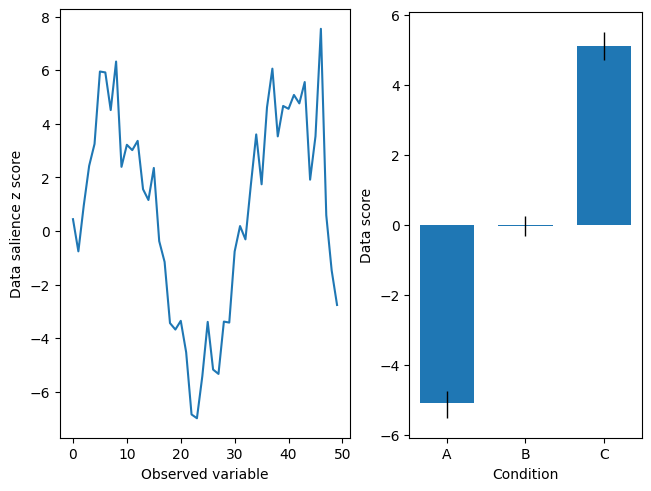

In [28]:
f, ax = plt.subplots(ncols=2, layout='constrained')
ax[0].plot(mod.data_sals_z_[:, 0])
ax[0].set_ylabel('Data salience z score')
ax[0].set_xlabel('Observed variable')
mod.plot_boot_stat(0, ax=ax[1]);